#Amazon Sales Data Analysis


###Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Download Dataset

In [ ]:
df = pd.read_csv('Amazon Sale Report.csv', engine='python')

## Dataset Overview

In [ ]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
df.shape

(128975, 24)

In [ ]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [ ]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


## Data Types and Basic Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [ ]:
df[['Amount','Qty']].describe()

,Amount,Qty
count,121180.000000,128975.000000
mean,648.561465,0.904431
std,281.211687,0.313354
min,0.000000,0.000000
25%,449.000000,1.000000
50%,605.000000,1.000000
75%,788.000000,1.000000
max,5584.000000,15.000000


In [ ]:
df['Status'].value_counts()

,count
Status,
Shipped,77804
Shipped - Delivered to Buyer,28769
Cancelled,18332
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


# Data Cleaning

In this section, we clean the dataset by removing unnecessary columns, handling missing values, and correcting data types.

In [ ]:
df.drop(columns=['index','Unnamed: 22'],inplace=True)

# Missing Value Analysis

Understanding missing data helps improve data quality and ensures reliable analysis.

In [ ]:
missing= df.isnull().sum()


In [ ]:
missing

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
missing[missing>0].sort_values(ascending=False)

,0
fulfilled-by,89698
promotion-ids,49153
currency,7795
Amount,7795
Courier Status,6872
ship-state,33
ship-city,33
ship-country,33
ship-postal-code,33


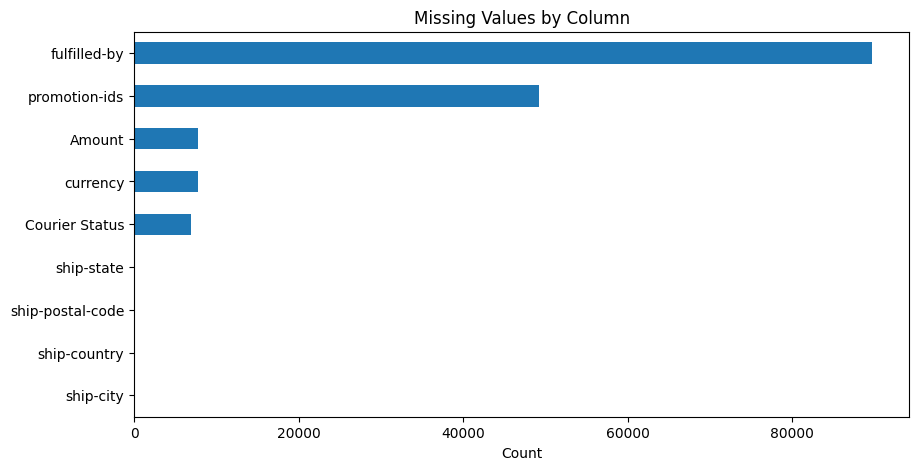

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')
plt.title('Missing Values by Column')
plt.xlabel('Count')
plt.show()

In [ ]:
df.shape

(128975, 22)

## Investigating Missing Revenue Values

In [ ]:
df[df['Amount'].isnull()][['Status','Amount']].head(20)

,Status,Amount
8,Cancelled,NaN
29,Cancelled,NaN
65,Cancelled,NaN
84,Cancelled,NaN
95,Cancelled,NaN
101,Cancelled,NaN
132,Cancelled,NaN
139,Cancelled,NaN
155,Cancelled,NaN
165,Cancelled,NaN


In [ ]:
df[df['Amount'].isnull()]['Status'].value_counts()

,count
Status,
Cancelled,7566
Shipped,208
Shipped - Delivered to Buyer,8
Shipping,8
Shipped - Returned to Seller,3
Pending,2


## Handling Missing Revenue Values

Orders with missing revenue are removed because most correspond to cancelled orders and do not represent actual sales.

In [ ]:
df = df.dropna(subset=['Amount'])

In [ ]:
df.shape

(121180, 22)

In [ ]:
df['fulfilled-by'].value_counts(dropna=False)

,count
fulfilled-by,
NaN,83639
Easy Ship,37541


## Removing the fulfilled-by Column

The fulfilled-by column contained only one meaningful category (Easy Ship) and a large number of missing values. Since it provides limited analytical value, it was removed.

In [ ]:
df.drop(columns=['fulfilled-by'],inplace=True)

In [ ]:
df.shape

(121180, 21)

In [ ]:
df['promotion-ids'].value_counts(dropna=False).head(10)

,count
promotion-ids,
IN Core Free Shipping 2015/04/08 23-48-5-108,45762
NaN,41698
Duplicated A12RHGVGRWOT3S 1560498941486,488
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-XX7G3ZRJJJ5LG,Amazon PLCC Free-Financing Universal Merchant AAT-LEHCKNDBJG64E,Amazon PLCC Free-Financing Universal Merchant AAT-DJVHCEV7D7RQY,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",458
Duplicated AYTJSBA8ZOP16 1567159860988,433
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-ETXQ3XXWMRXBG,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",316
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Free-Financing Universal Merchant AAT-BRSZZ45H6MHAO,Amazon PLCC Free-Financing Universal Merchant AAT-MKLXOOZWQL7GO,Amazon PLCC Free-Financing Universal Merchant AAT-CB7UNXEXGIJTC,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811,Amazon PLCC Free-Financing Universal Merchant AAT-WLBA4GZ52EAH4",305
"Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-G5ZRX4BZOIODU,Amazon PLCC Free-Financing Universal Merchant AAT-PZHUW6DZX4BPS,Amazon PLCC Fr

## Handling Missing Promotion Values

Missing promotion IDs are treated as orders where no promotion was applied.

In [ ]:
df['promotion-ids']=df['promotion-ids'].fillna('No Promotion')

In [ ]:
df['promotion-ids'].isnull().sum()

np.int64(0)

In [ ]:
df['currency'].value_counts(dropna=False)

,count
currency,
INR,121180


In [ ]:
df['currency'].isnull().sum()

np.int64(0)

In [ ]:
df['Courier Status'].value_counts(dropna=False)

,count
Courier Status,
Shipped,109487
Unshipped,6557
NaN,5136


In [ ]:
df[df['Courier Status'].isnull()]['Status'].value_counts()

,count
Status,
Cancelled,5136


## Handling Missing Courier Status

Analysis showed that all missing Courier Status values belonged to cancelled orders. Therefore, missing values were replaced with "Cancelled" to preserve the business meaning of the data.

In [ ]:
df['Courier Status'] = df['Courier Status'].fillna('Cancelled')

In [ ]:
df['Courier Status'].isnull().sum()

np.int64(0)

In [ ]:
df[df['ship-state'].isnull()][
    ['Status','ship-state','ship-city']
].head(20)

,Status,ship-state,ship-city
1871,Shipped,NaN,NaN
1872,Shipped,NaN,NaN
8752,Shipped,NaN,NaN
11215,Shipped,NaN,NaN
13252,Cancelled,NaN,NaN
15688,Shipped,NaN,NaN
16787,Shipped - Delivered to Buyer,NaN,NaN
18351,Shipped,NaN,NaN
22930,Shipped - Returned to Seller,NaN,NaN
24986,Cancelled,NaN,NaN


## Handling Missing Location Information

A very small number of records (33 rows) contained missing shipping information such as city, state, country, and postal code. Since these records represented less than 0.03% of the dataset and location information could not be reliably inferred, they were removed.

In [ ]:
df = df.dropna(
    subset=[
        'ship-state',
        'ship-city',
        'ship-country',
        'ship-postal-code'
    ]
)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_3316/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121149 entries, 0 to 128974
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            121149 non-null  object        
 1   Date                121149 non-null  datetime64[ns]
 2   Status              121149 non-null  object        
 3   Fulfilment          121149 non-null  object        
 4   Sales Channel       121149 non-null  object        
 5   ship-service-level  121149 non-null  object        
 6   Style               121149 non-null  object        
 7   SKU                 121149 non-null  object        
 8   Category            121149 non-null  object        
 9   Size                121149 non-null  object        
 10  ASIN                121149 non-null  object        
 11  Courier Status      121149 non-null  object        
 12  Qty                 121149 non-null  int64         
 13  currency            121149 non-nul

## Date Conversion

Convert the Date column into datetime format for time-series analysis.

In [ ]:
df['Date'].head()

,Date
0,2022-04-30
1,2022-04-30
2,2022-04-30
3,2022-04-30
4,2022-04-30


# Key Performance Indicators (KPIs)

This section provides a high-level overview of business performance.

In [ ]:
total_revenue = df['Amount'].sum()

total_orders = df['Order ID'].nunique()

total_quantity = df['Qty'].sum()

average_order_value = df['Amount'].mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value,2))

Total Revenue: 78574007.3
Total Orders: 113004
Total Quantity Sold: 116454
Average Order Value: 648.57


In [ ]:
df['Amount'].sum()

np.float64(78574007.3)

In [ ]:
df['Order ID'].nunique()

113004

In [ ]:
df['Qty'].sum()

np.int64(116454)

In [ ]:
df['Amount'].mean()

np.float64(648.5733047734608)

## Revenue by Product Category

Analyze revenue contribution from different product categories.

In [ ]:
category_sales = df.groupby('Category')['Amount'].sum()

category_sales = category_sales.sort_values(ascending=False)

category_sales

,Amount
Category,
Set,39195176.03
kurta,21291538.70
Western Dress,11215337.69
Top,5346812.30
Ethnic Dress,791217.66
Blouse,458408.18
Bottom,150667.98
Saree,123933.76
Dupatta,915.00


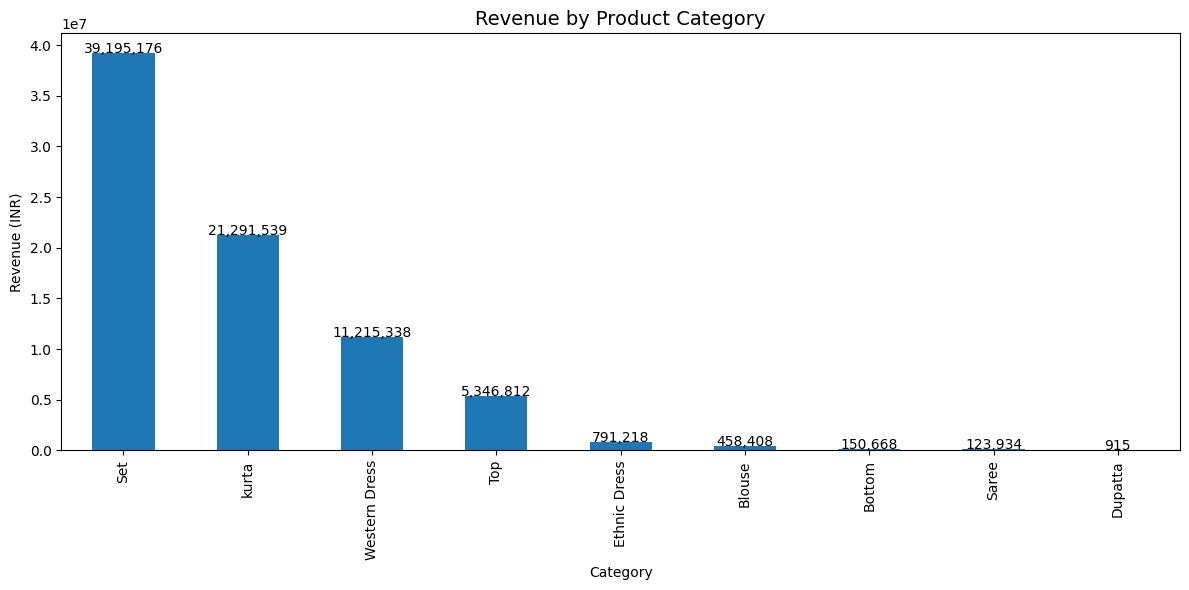

In [ ]:
plt.figure(figsize=(12,6))

category_sales.plot(
    kind='bar'
)

plt.title('Revenue by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Revenue (INR)')

for i, value in enumerate(category_sales):
    plt.text(i, value, f'{value:,.0f}', ha='center')

plt.tight_layout()

plt.show()

In [ ]:
category_sales.head(10)

,Amount
Category,
Set,39195176.03
kurta,21291538.70
Western Dress,11215337.69
Top,5346812.30
Ethnic Dress,791217.66
Blouse,458408.18
Bottom,150667.98
Saree,123933.76
Dupatta,915.00


## Top 10 States by Revenue

Identify the states contributing the highest revenue.

In [ ]:
state_sales = df.groupby('ship-state')['Amount'].sum()

state_sales = state_sales.sort_values(ascending=False)

state_sales.head(10)

,Amount
ship-state,
MAHARASHTRA,13335534.14
KARNATAKA,10481114.37
TELANGANA,6916615.65
UTTAR PRADESH,6816642.08
TAMIL NADU,6515650.11
DELHI,4235215.97
KERALA,3830227.58
WEST BENGAL,3507880.44
ANDHRA PRADESH,3219831.72


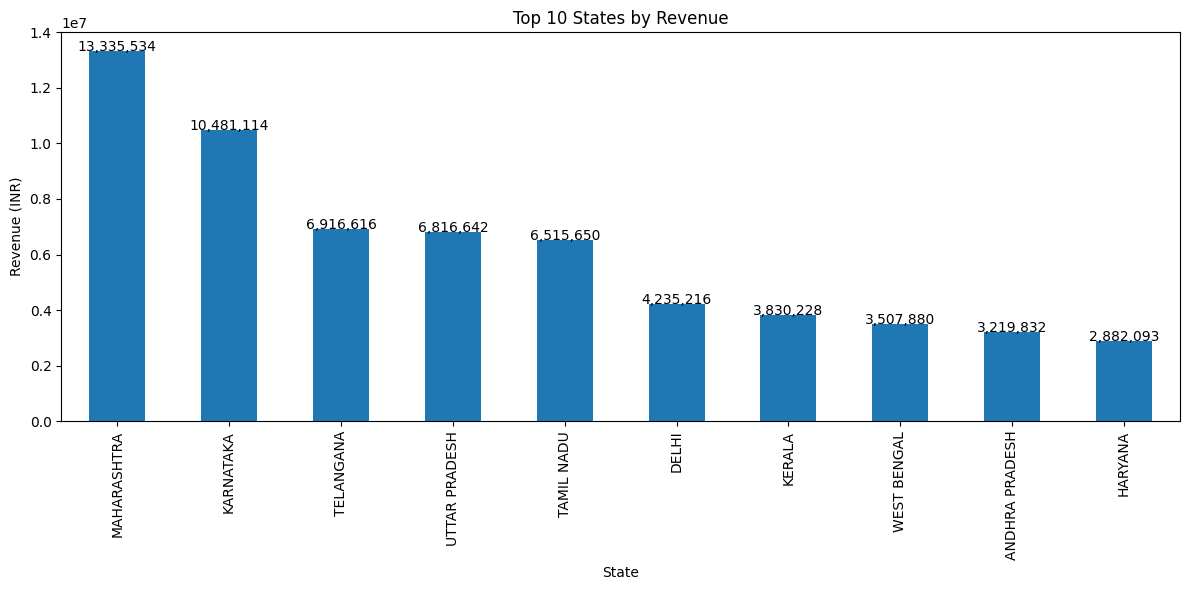

In [ ]:
top_states = state_sales.head(10)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue (INR)')

for i, value in enumerate(top_states):
    plt.text(i, value, f'{value:,.0f}', ha='center')

plt.tight_layout()

plt.show()

In [ ]:
state_sales.head(10)

,Amount
ship-state,
MAHARASHTRA,13335534.14
KARNATAKA,10481114.37
TELANGANA,6916615.65
UTTAR PRADESH,6816642.08
TAMIL NADU,6515650.11
DELHI,4235215.97
KERALA,3830227.58
WEST BENGAL,3507880.44
ANDHRA PRADESH,3219831.72


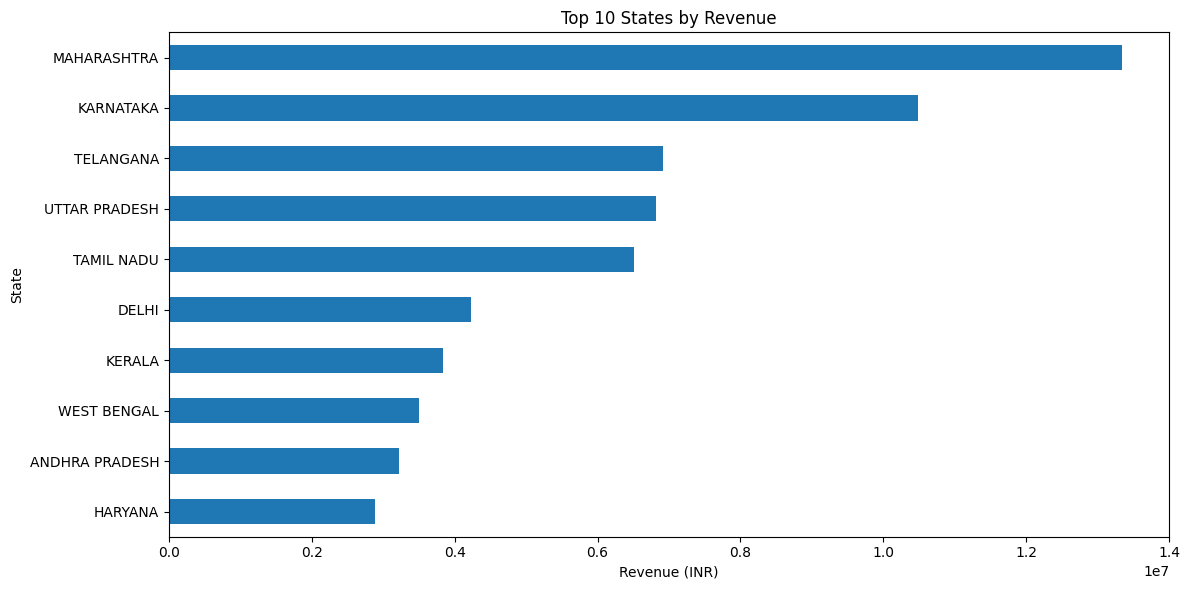

In [ ]:
top_states = state_sales.head(10)

plt.figure(figsize=(12,6))

top_states.sort_values().plot(kind='barh')

plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue (INR)')
plt.ylabel('State')

plt.tight_layout()

plt.show()

## Order Status Analysis

Analyze the distribution of orders across different statuses.

In [ ]:
status_counts = df['Status'].value_counts()

status_counts

,count
Status,
Shipped,77580
Shipped - Delivered to Buyer,28754
Cancelled,10761
Shipped - Returned to Seller,1947
Shipped - Picked Up,973
Pending,656
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


## Order Status Distribution

Analyze fulfillment performance and order outcomes.

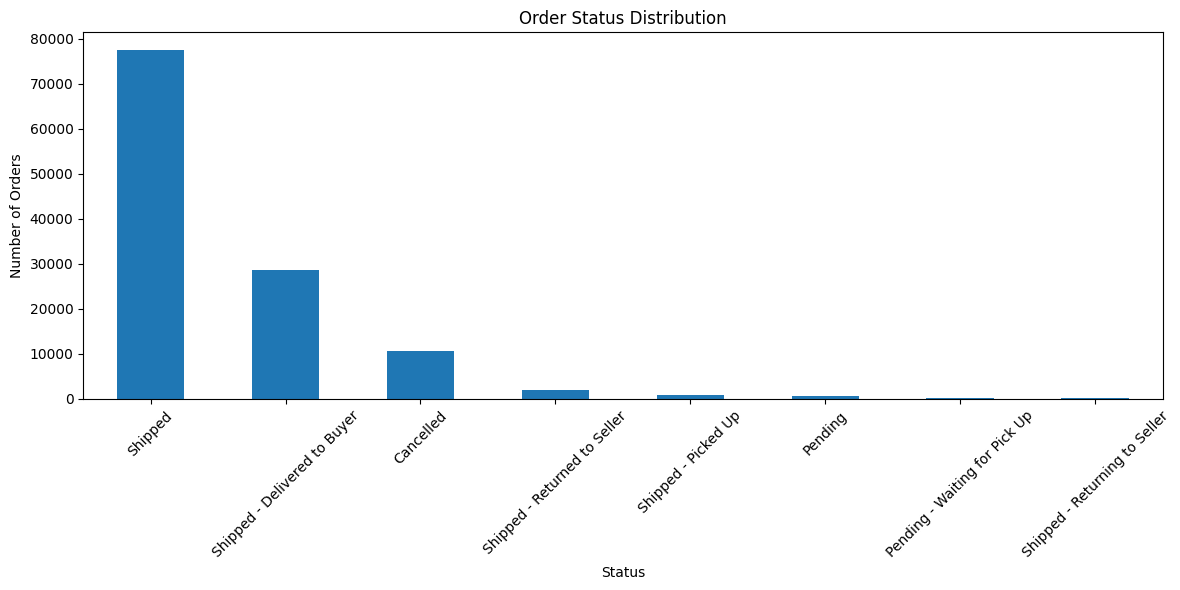

In [ ]:
status_counts = df['Status'].value_counts().head(8)

plt.figure(figsize=(12,6))

status_counts.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Monthly Revenue Trend

Analyze how revenue changes over time.

In [ ]:
df['Month'] = df['Date'].dt.month_name()

In [ ]:
df[['Date','Month']].head()

,Date,Month
0,2022-04-30,April
1,2022-04-30,April
2,2022-04-30,April
3,2022-04-30,April
4,2022-04-30,April


In [ ]:
df['Month'] = df['Date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

In [ ]:
monthly_sales = df.groupby('Month')['Amount'].sum()

monthly_sales

/tmp/ipykernel_3316/295155886.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month')['Amount'].sum()


,Amount
Month,
January,0.00
February,0.00
March,101683.85
April,28831249.32
May,26219850.75
June,23421223.38
July,0.00
August,0.00
September,0.00


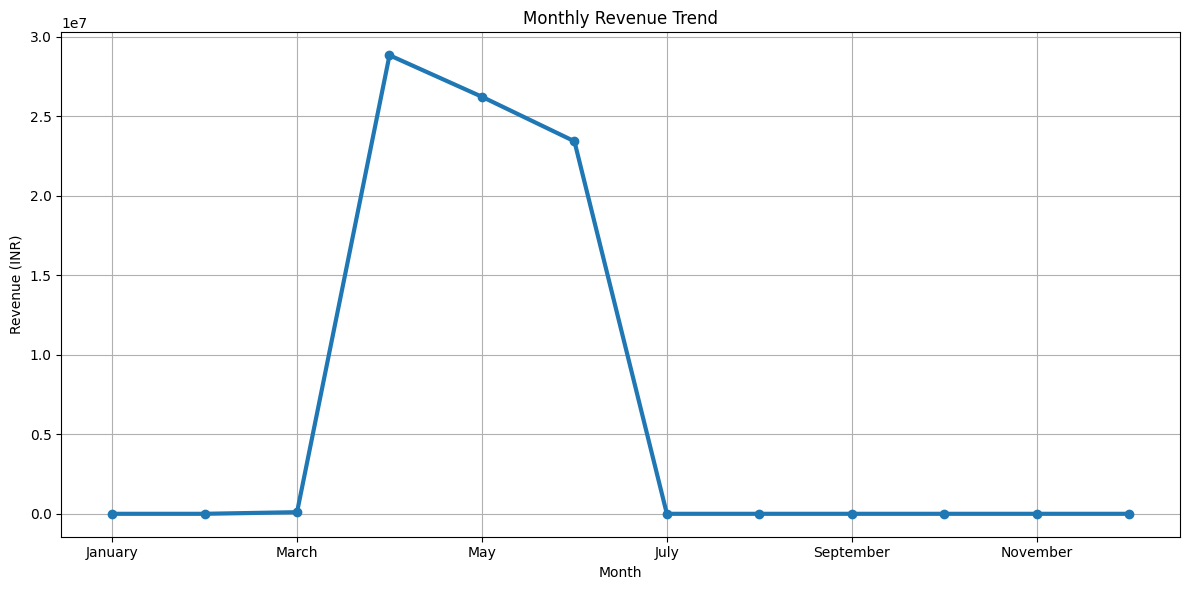

In [ ]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')

plt.grid(True)

plt.tight_layout()

plt.show()

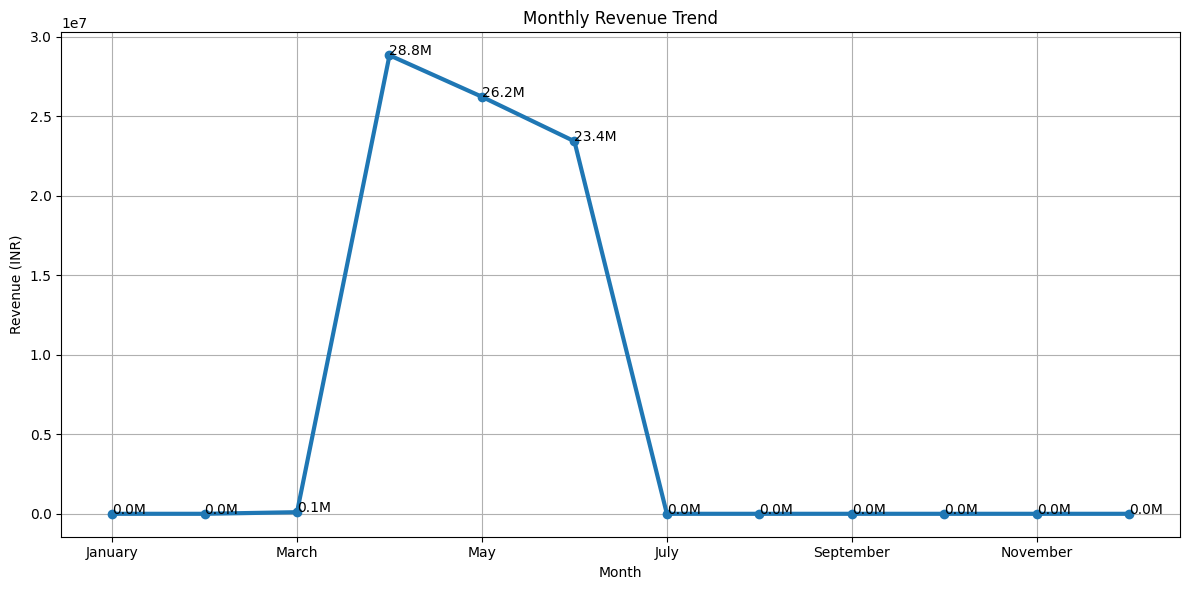

In [ ]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

for i, value in enumerate(monthly_sales):
    plt.text(i, value, f'{value/1000000:.1f}M')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
monthly_sales

,Amount
Month,
January,0.00
February,0.00
March,101683.85
April,28831249.32
May,26219850.75
June,23421223.38
July,0.00
August,0.00
September,0.00


In [ ]:
df['Date'].min()

Timestamp('2022-03-31 00:00:00')

In [ ]:
df['Date'].max()

Timestamp('2022-06-29 00:00:00')

In [ ]:
df['Date'].dt.month.value_counts().sort_index()

,count
Date,
3,162
4,46055
5,39525
6,35407


In [ ]:
monthly_sales = df.groupby(
    df['Date'].dt.month_name()
)['Amount'].sum()

In [ ]:
df['Date'].min()
df['Date'].max()
df['Date'].dt.month.value_counts().sort_index()

,count
Date,
3,162
4,46055
5,39525
6,35407


Correct Monthly Revenue Analysis

In [ ]:
monthly_sales = df.groupby(
    df['Date'].dt.month_name()
)['Amount'].sum()

monthly_sales

,Amount
Date,
April,28831249.32
June,23421223.38
March,101683.85
May,26219850.75


In [ ]:
month_order = ['March', 'April', 'May', 'June']

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales

,Amount
Date,
March,101683.85
April,28831249.32
May,26219850.75
June,23421223.38


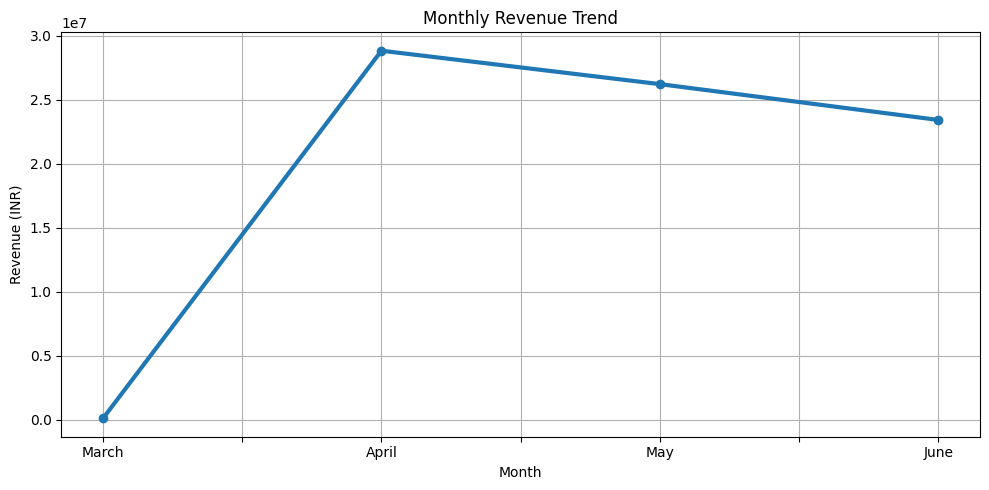

In [ ]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')

plt.grid(True)

plt.tight_layout()

plt.show()

## Top Cities by Revenue

Identify cities generating the highest revenue.

In [ ]:
city_sales = df.groupby('ship-city')['Amount'].sum()

city_sales = city_sales.sort_values(
    ascending=False
)

city_sales.head(10)

,Amount
ship-city,
BENGALURU,6849664.99
HYDERABAD,4946032.82
MUMBAI,3704461.80
NEW DELHI,3613874.78
CHENNAI,3098745.74
PUNE,2338518.18
KOLKATA,1414978.87
GURUGRAM,1221618.74
THANE,1004355.29


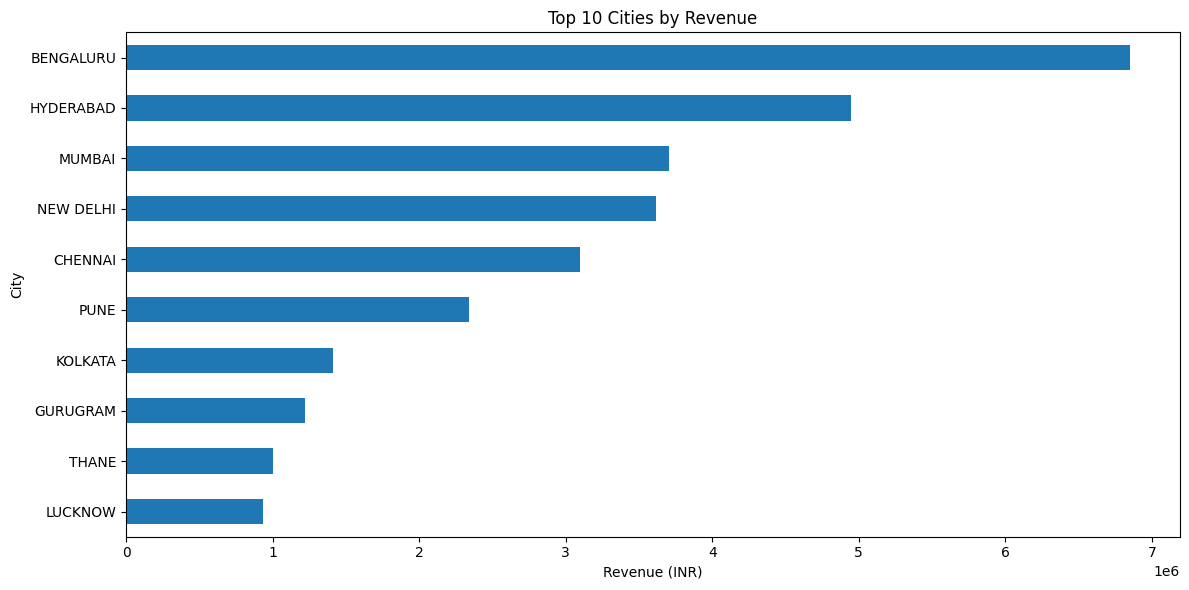

In [ ]:
top_cities = city_sales.head(10)

plt.figure(figsize=(12,6))

top_cities.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Cities by Revenue')
plt.xlabel('Revenue (INR)')
plt.ylabel('City')

plt.tight_layout()

plt.show()

## Size Analysis

Analyze which clothing sizes are most frequently purchased.

In [ ]:
size_qty = df.groupby('Size')['Qty'].sum()

size_qty = size_qty.sort_values(
    ascending=False
)

size_qty

,Qty
Size,
M,20422
L,19963
XL,18898
XXL,16487
S,15309
3XL,13505
XS,9928
6XL,687
5XL,512


In [ ]:
size_qty.head(15)

,Qty
Size,
M,20422
L,19963
XL,18898
XXL,16487
S,15309
3XL,13505
XS,9928
6XL,687
5XL,512


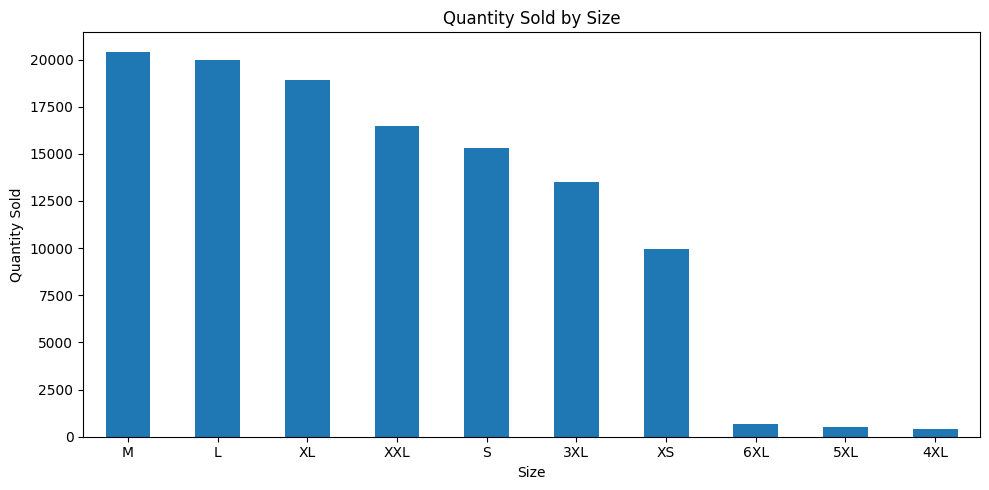

In [ ]:
top_sizes = size_qty.head(10)

plt.figure(figsize=(10,5))

top_sizes.plot(kind='bar')

plt.title('Quantity Sold by Size')
plt.xlabel('Size')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## B2B vs B2C Analysis

Compare revenue generated from business customers and individual customers.

In [ ]:
df['B2B'].value_counts()

,count
B2B,
False,120306
True,843


In [ ]:
b2b_percentage = (df['B2B'].sum() / len(df)) * 100

print(f"B2B Percentage: {b2b_percentage:.2f}%")
print(f"B2C Percentage: {100-b2b_percentage:.2f}%")

B2B Percentage: 0.70%
B2C Percentage: 99.30%


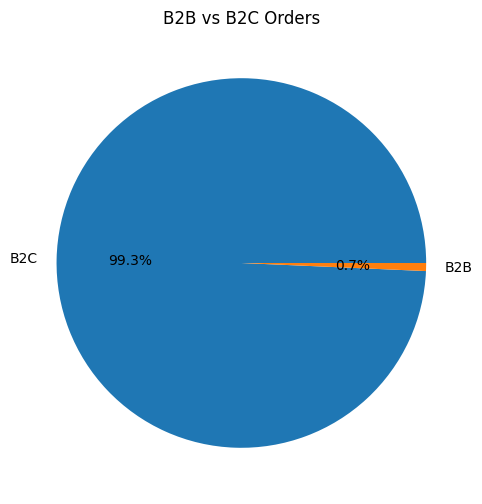

In [ ]:
b2b_counts = df['B2B'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    b2b_counts,
    labels=['B2C','B2B'],
    autopct='%1.1f%%'
)

plt.title('B2B vs B2C Orders')

plt.show()

In [ ]:
df.groupby('B2B')['Amount'].sum()

,Amount
B2B,
False,77982786.51
True,591220.79


In [ ]:
revenue_share = (df.groupby('B2B')['Amount'].sum() / df['Amount'].sum()) * 100

print(revenue_share)

B2B
False    99.247562
True      0.752438
Name: Amount, dtype: float64


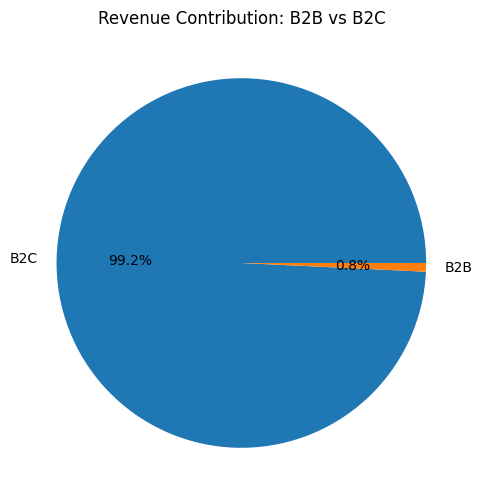

In [ ]:
revenue_b2b = df.groupby('B2B')['Amount'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    revenue_b2b,
    labels=['B2C','B2B'],
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution: B2B vs B2C')

plt.show()

Cancellation Rate

In [ ]:
total_orders = len(df)

cancelled_orders = len(
    df[df['Status'] == 'Cancelled']
)

cancellation_rate = (
    cancelled_orders / total_orders
) * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 8.88%


The cancellation rate was 8.88%, indicating that approximately 1 in 11 orders were cancelled before completion. Reducing cancellations could significantly improve overall revenue and operational efficiency.

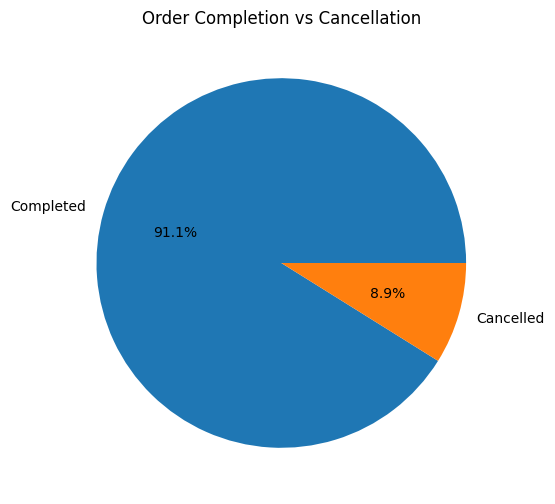

In [ ]:
status_summary = {
    'Completed': len(df) - len(df[df['Status'] == 'Cancelled']),
    'Cancelled': len(df[df['Status'] == 'Cancelled'])
}

plt.figure(figsize=(6,6))

plt.pie(
    status_summary.values(),
    labels=status_summary.keys(),
    autopct='%1.1f%%'
)

plt.title('Order Completion vs Cancellation')

plt.show()

In [ ]:
returned_orders = len(
    df[df['Status'] == 'Shipped - Returned to Seller']
)

return_rate = (
    returned_orders / len(df)
) * 100

print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 1.61%


The return rate was 1.61%, indicating that only a small percentage of fulfilled orders were returned. This suggests satisfactory product quality and customer experience.

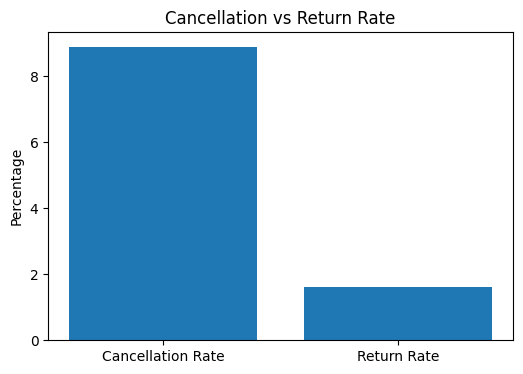

In [ ]:
rates = {
    'Cancellation Rate': 8.88,
    'Return Rate': 1.61
}

plt.figure(figsize=(6,4))

plt.bar(rates.keys(), rates.values())

plt.title('Cancellation vs Return Rate')
plt.ylabel('Percentage')

plt.show()

In [ ]:
top_sku = df.groupby('SKU')['Amount'].sum()

top_sku = top_sku.sort_values(
    ascending=False
)

top_sku.head(10)

,Amount
SKU,
J0230-SKD-M,527699.20
JNE3797-KR-L,524581.77
J0230-SKD-S,479937.14
JNE3797-KR-M,453555.16
JNE3797-KR-S,407302.57
JNE3797-KR-XL,332155.24
J0230-SKD-L,305616.95
JNE3797-KR-XS,303616.70
SET268-KR-NP-XL,284058.96


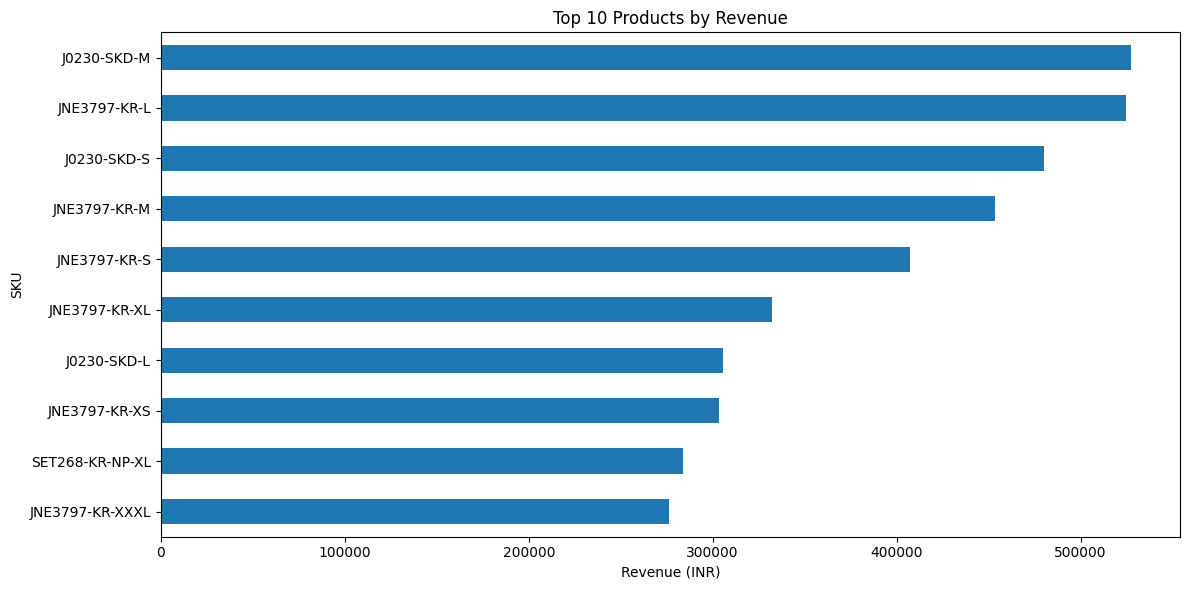

In [ ]:
top_sku = top_sku.head(10)

plt.figure(figsize=(12,6))

top_sku.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (INR)')
plt.ylabel('SKU')

plt.tight_layout()

plt.show()

In [ ]:
top_styles = df.groupby('Style')['Amount'].sum()

top_styles = top_styles.sort_values(
    ascending=False
)

top_styles.head(10)

,Amount
Style,
JNE3797,2932747.00
J0230,1943836.48
SET268,1303923.56
J0341,1275322.87
J0003,980665.75
JNE3405,846062.36
J0008,819169.96
SET345,723402.79
SET278,719791.48


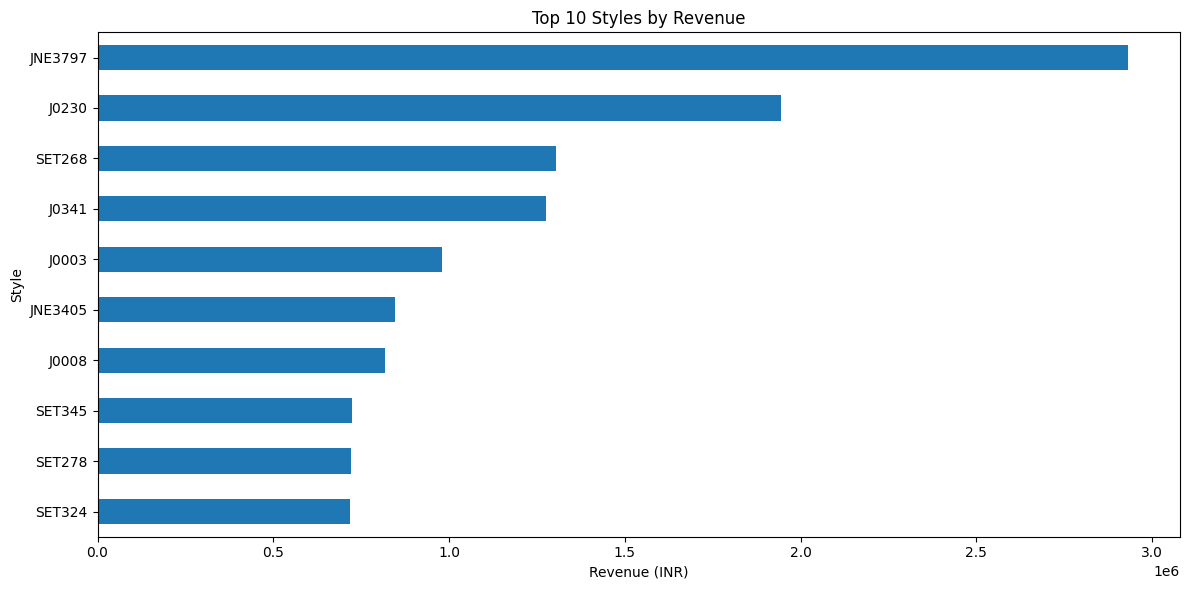

In [ ]:
top_styles = top_styles.head(10)

plt.figure(figsize=(12,6))

top_styles.sort_values().plot(kind='barh')

plt.title('Top 10 Styles by Revenue')
plt.xlabel('Revenue (INR)')
plt.ylabel('Style')

plt.tight_layout()

plt.show()